<a href="https://colab.research.google.com/github/marcovirulucas/econ_apis/blob/main/united_states/Fiscal_Data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Fiscal Data API with Python
## Budget Deficit (Billions of USD)
------
*May 12, 2026*\
\
The documentation about Fiscal Data API can be found [here](https://fiscaldata.treasury.gov/api-documentation/).\
\
This script collects data on Budget Deficit (Billions of USD) of the Monthly Treasury Statement from the United States.

In [1]:
import requests
import pandas as pd

### Base URL and Endpoint

In [2]:
base = 'https://api.fiscaldata.treasury.gov/services/api/fiscal_service'
endpoint = '/v1/accounting/mts/mts_table_2'

### Parameters

In [3]:
# Parameters
fields = '?fields=record_date,parent_id,classification_id,classification_desc,current_fytd_budget_amt'
sort = '&sort=-record_date'
format = '&format=json'
pagination = '&page[number]=1&page[size]=102'
url = f'{base}{endpoint}{fields}{sort}{format}{pagination}'

### Request the data

In [4]:
# Make a request to an URL and store the JSON data in a dictionary format
data = requests.get(url).json()

In [5]:
# Construct the dataframe
df = pd.DataFrame(data['data'])

In [6]:
df

,record_date,parent_id,classification_id,classification_desc,current_fytd_budget_amt
0,2026-04-30,58331728,58331736,On-Budget Surplus (+) or Deficit (-),-876770493212.25
1,2026-04-30,58331728,58331746,Off-Budget Surplus (+) or Deficit (-),-76784306090.94
2,2026-04-30,null,58331761,Means of Financing:,null
3,2026-04-30,58331761,58331778,"Reduction of Operating Cash, Increase (-)",-78557846491.19
4,2026-04-30,58331761,58331786,By Other Means,99694774727.79
...,...,...,...,...,...
97,2025-10-31,57430458,57430466,Total Surplus (+) or Deficit (-),-284350050782.80
98,2025-10-31,57430466,57430467,On-Budget Surplus (+) or Deficit (-),-254879285798.22
99,2025-10-31,57430466,57430468,Off-Budget Surplus (+) or Deficit (-),-29470764984.58
100,2025-10-31,57430458,57430469,Total On-Budget and Off-Budget Financing,284350050782.80


In [7]:
# Filter for the specific indicator
indicator = "Total Surplus (+) or Deficit (-)"
deficit = df[df['classification_desc'] == indicator].copy()

deficit

,record_date,parent_id,classification_id,classification_desc,current_fytd_budget_amt
12,2026-04-30,58331676,58331728,Total Surplus (+) or Deficit (-),-953554799303.19
16,2026-03-31,58130014,58130052,Total Surplus (+) or Deficit (-),-1168578964500.96
44,2026-02-28,57948882,57948941,Total Surplus (+) or Deficit (-),-1004478625683.10
59,2026-01-31,57770116,57770169,Total Surplus (+) or Deficit (-),-696977192256.93
67,2025-12-31,57633895,57633929,Total Surplus (+) or Deficit (-),-602376461515.00
82,2025-11-30,57508364,57508426,Total Surplus (+) or Deficit (-),-457627225859.72
97,2025-10-31,57430458,57430466,Total Surplus (+) or Deficit (-),-284350050782.80


In [8]:
# Convert the column "current_fytd_budget_amt" to numeric
deficit['current_fytd_budget_amt'] = pd.to_numeric(deficit['current_fytd_budget_amt'])

# Convert values to absolute (positive), scale to billions, round, and save as integers
deficit["billions"] = (deficit["current_fytd_budget_amt"].abs() / 1e9).round().astype(int)

In [9]:
# Order the dataframe based on the "record_date" column
deficit = deficit.sort_values(by='record_date', ascending=True).reset_index(drop=True)
deficit


,record_date,parent_id,classification_id,classification_desc,current_fytd_budget_amt,billions
0,2025-10-31,57430458,57430466,Total Surplus (+) or Deficit (-),-2.843501e+11,284
1,2025-11-30,57508364,57508426,Total Surplus (+) or Deficit (-),-4.576272e+11,458
2,2025-12-31,57633895,57633929,Total Surplus (+) or Deficit (-),-6.023765e+11,602
3,2026-01-31,57770116,57770169,Total Surplus (+) or Deficit (-),-6.969772e+11,697
4,2026-02-28,57948882,57948941,Total Surplus (+) or Deficit (-),-1.004479e+12,1004
5,2026-03-31,58130014,58130052,Total Surplus (+) or Deficit (-),-1.168579e+12,1169
6,2026-04-30,58331676,58331728,Total Surplus (+) or Deficit (-),-9.535548e+11,954


### Plot the results

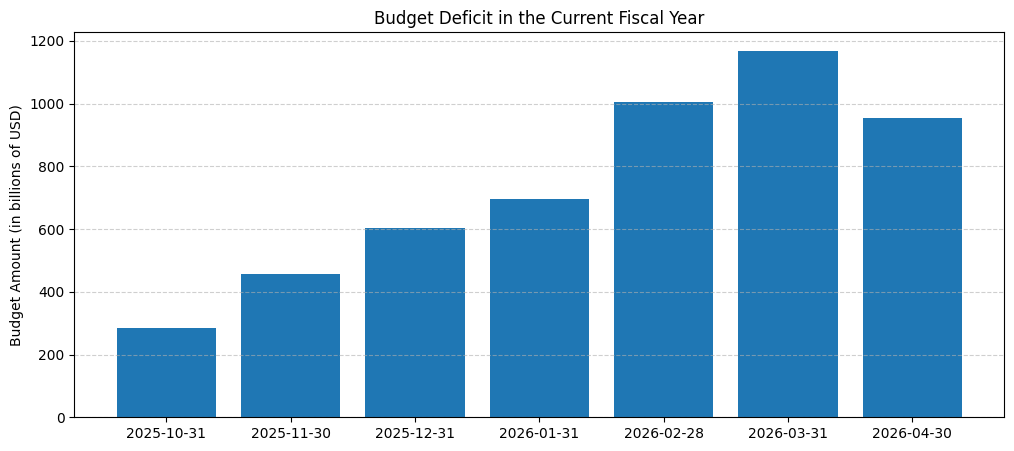

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
plt.bar(deficit['record_date'], deficit['billions'])
plt.ylabel('Budget Amount (in billions of USD)')
plt.title('Budget Deficit in the Current Fiscal Year')
plt.grid(True, axis='y', linestyle='--', alpha=0.6)
plt.show()